# Define constants

In [10]:
import librosa
from os import path

SOURCE_PATH = path.normpath("../validations/")

# Least audio duration
AUDIO_SAMPLE_RATE = 48_000 # Hz

# How many frames to skip in each samples
CQT_HOP_LENGTH = 512

# Bin numbers based on octaves for input
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36

# Starts from note
CQT_FMIN = librosa.note_to_hz('C1')

print({
  "feature bins": CQT_BINS_PER_OCTAVE * CQT_OCTAVES,
  "feature start Hz": CQT_FMIN,
})

{'feature bins': 216, 'feature start Hz': 32.70319566257483}


# Extract datasets

In [11]:
from os import listdir, path
from tqdm.notebook import tqdm
import numpy as np
import warnings
import os

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def target_npz_path(dataset_name):
    return path.join(SOURCE_PATH, f"{dataset_name}.npz")

def extract_cqt_features(audio_path):
    """Extracts raw CQT features from an audio file."""
    try:
        y, sr = librosa.load(audio_path, sr=AUDIO_SAMPLE_RATE)
        cqt = librosa.cqt(
            y=y,
            sr=sr,
            fmin=CQT_FMIN,
            n_bins=CQT_BINS_PER_OCTAVE * CQT_OCTAVES,
            bins_per_octave=CQT_BINS_PER_OCTAVE,
            hop_length=CQT_HOP_LENGTH,
            window='hann',
        )
        return np.abs(cqt)
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

def normalize_chord(chord):
    chord = chord.replace(":", "_")
    chord = chord.replace("_maj", "_major")
    chord = chord.replace("_min", "_minor")
    chord = chord.replace("_dim", "_diminished")
    return f"{chord}_4"

def parse_annotation_file(annotation_path):
    annotations = []
    try:
        with open(annotation_path, "r", encoding="utf-8") as annotation_file:
            for line in annotation_file:
                line = line.strip()
                if not line:
                    continue

                start_str, end_str, chord = line.split(maxsplit=2)
                annotations.append({
                    "start": float(start_str),
                    "end": float(end_str),
                    "chord": normalize_chord(chord),
                })
    except Exception as e:
        print(f"Error processing {annotation_path}: {e}")

    return annotations

validation_datasets = [d for d in os.listdir(SOURCE_PATH) if os.path.isdir(os.path.join(SOURCE_PATH, d))]

for dataset_name in tqdm(listdir(SOURCE_PATH), desc="Processing validation sets"):
    dataset_path = path.join(SOURCE_PATH, dataset_name)
    if not path.isdir(dataset_path):
        continue

    features = []
    labels = []
    annotations = []

    for file_name in tqdm(listdir(dataset_path), desc=f"Processing {dataset_name}"):
        audio_path = path.join(dataset_path, file_name)
        if not path.isfile(audio_path) or not file_name.lower().endswith(".ogg"):
            continue

        cqt = extract_cqt_features(audio_path)
        if cqt is not None:
            features.append(cqt)
            labels.append(dataset_name)

            annotation_path = path.splitext(audio_path)[0] + ".txt"
            if path.isfile(annotation_path):
                annotations.append(parse_annotation_file(annotation_path))
            else:
                annotations.append([])

    npz_path = target_npz_path(dataset_name)
    features_array = np.empty(len(features), dtype=object)
    features_array[:] = features
    labels = np.array(labels)
    annotations_array = np.empty(len(annotations), dtype=object)
    annotations_array[:] = annotations
    np.savez(npz_path, features=features_array, labels=labels, annotations=annotations_array)
    print(f"Saved {len(features)} raw CQT features to {npz_path}")
    print(f"Shape of labels: {labels.shape}")
    print(f"Parsed {len(annotations)} annotation files for {dataset_name}")

Processing validation sets:   0%|          | 0/6 [00:00<?, ?it/s]

Processing normal_sustain:   0%|          | 0/20 [00:00<?, ?it/s]

Saved 10 raw CQT features to ../validations/normal_sustain.npz
Shape of labels: (10,)
Parsed 10 annotation files for normal_sustain


Processing broken_sustain:   0%|          | 0/40 [00:00<?, ?it/s]

Saved 20 raw CQT features to ../validations/broken_sustain.npz
Shape of labels: (20,)
Parsed 20 annotation files for broken_sustain


Processing normal_no-sustain:   0%|          | 0/64 [00:00<?, ?it/s]

Saved 32 raw CQT features to ../validations/normal_no-sustain.npz
Shape of labels: (32,)
Parsed 32 annotation files for normal_no-sustain


# Example plots

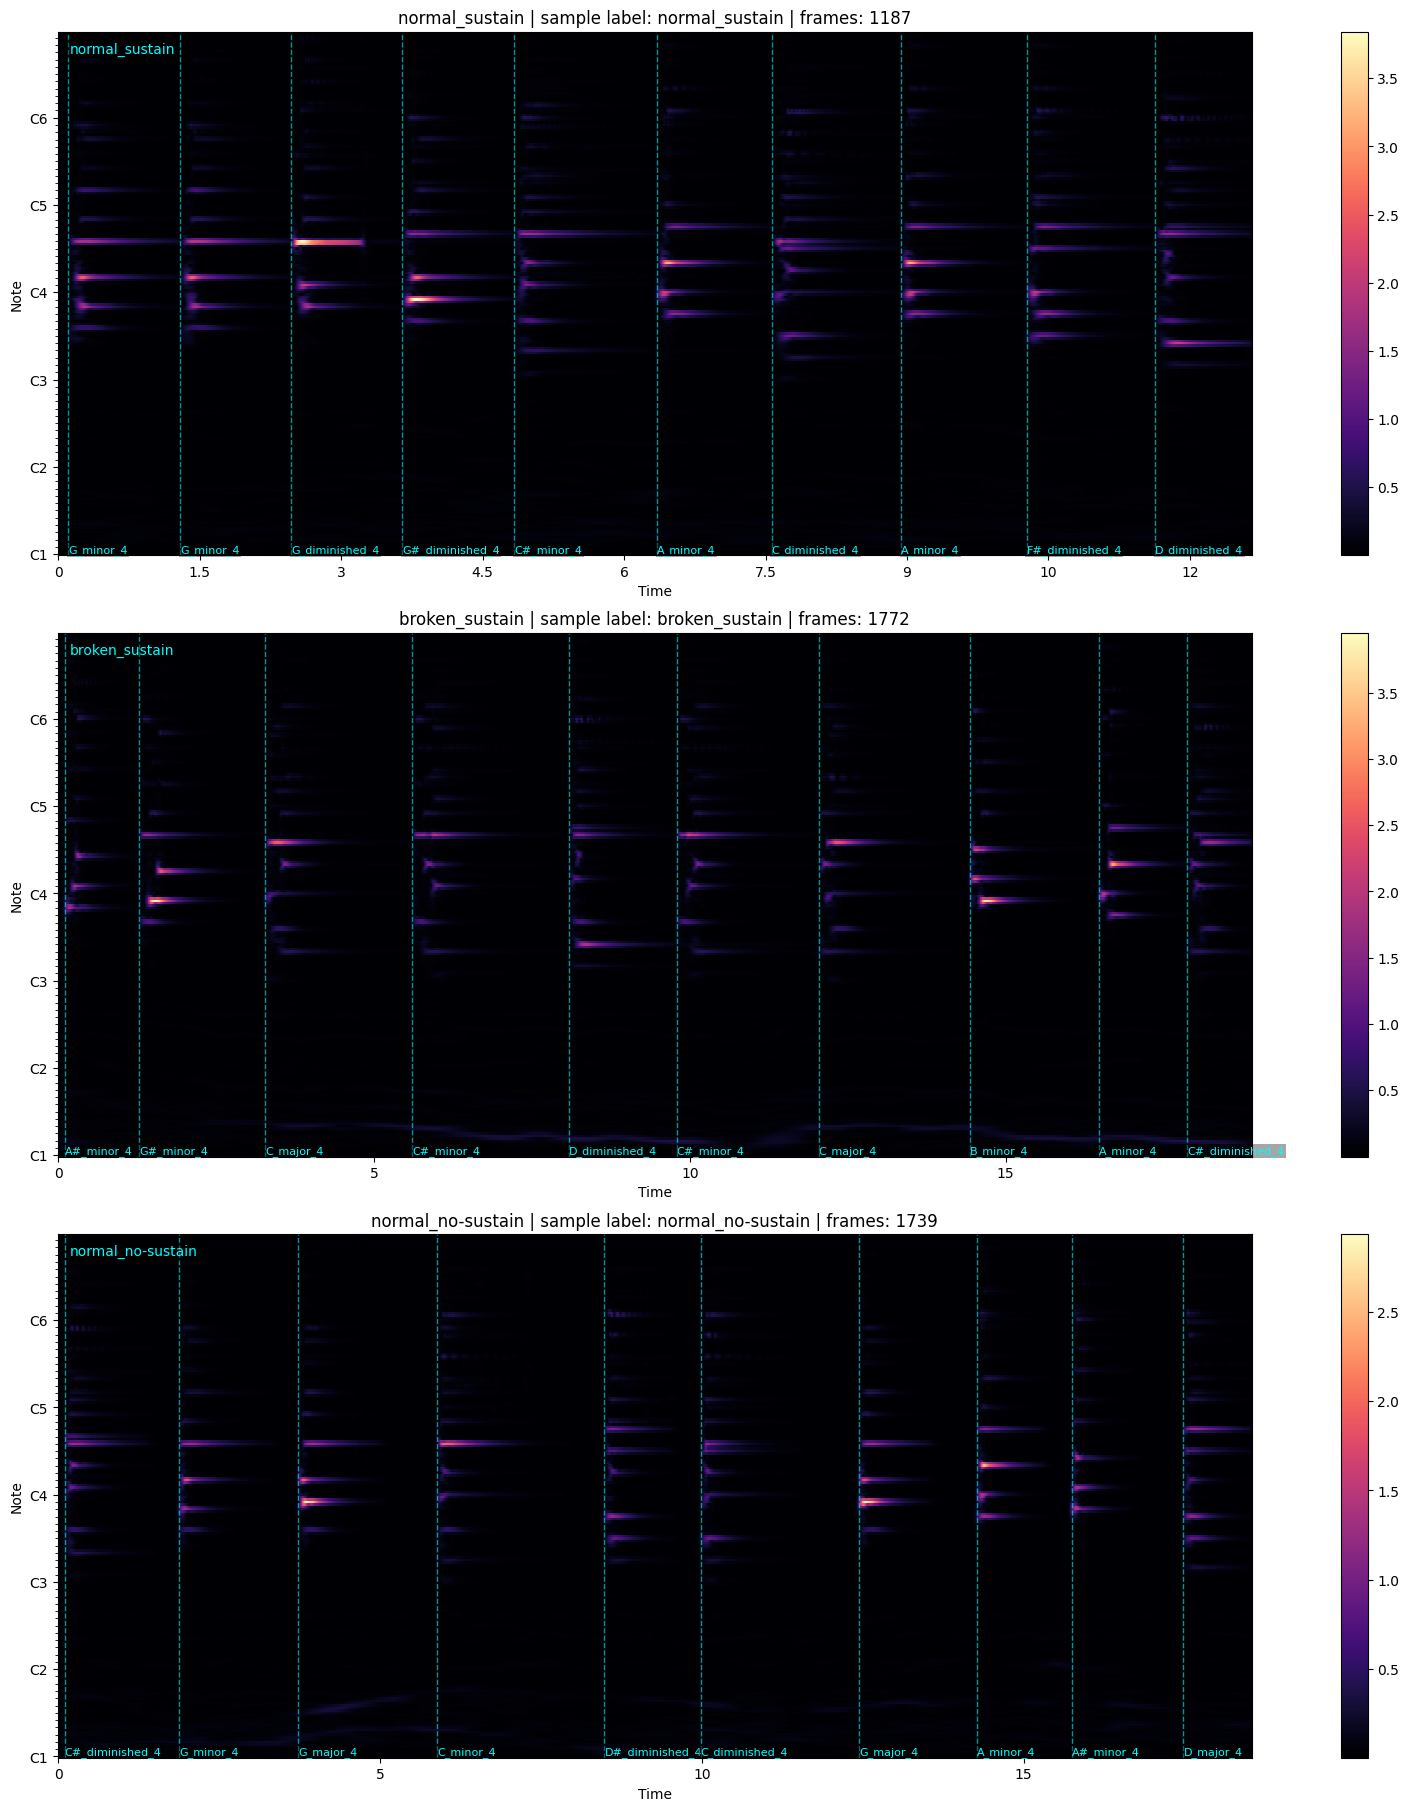

In [12]:
import matplotlib.pyplot as plt
import librosa.display
import os

fig, axes = plt.subplots(len(validation_datasets), 1, figsize=(14, 18), constrained_layout=True)

if len(validation_datasets) == 1:
    axes = [axes]

for axis, dataset_name in zip(axes, validation_datasets):
    npz_path = target_npz_path(dataset_name)
    data = np.load(npz_path, allow_pickle=True)
    features = data["features"]
    labels = data["labels"]
    annotations = data["annotations"][0]

    sample_cqt = features[0]
    librosa.display.specshow(
        sample_cqt,
        x_axis='time',
        y_axis='cqt_note',
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        fmin=CQT_FMIN,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
        ax=axis,
    )

    y_bottom = axis.get_ylim()[0]
    for annotation in annotations:
        onset_time = annotation["start"]
        chord_name = annotation["chord"]
        axis.axvline(onset_time, color="cyan", linestyle="--", linewidth=1, alpha=0.6)
        axis.text(
            onset_time,
            y_bottom,
            chord_name,
            va="bottom",
            ha="left",
            fontsize=8,
            color="cyan",
            bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=1),
        )

    axis.text(
        0.01,
        0.98,
        dataset_name,
        transform=axis.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        color="cyan",
        bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=2),
    )

    axis.set_title(f"{dataset_name} | sample label: {labels[0]} | frames: {sample_cqt.shape[1]}")
    fig.colorbar(axis.collections[0], ax=axis)

plt.show()